In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

Matplotlib is building the font cache; this may take a moment.


In [2]:
print("FinancialPulse AI is Ready 🚀")

FinancialPulse AI is Ready 🚀


In [4]:
import pandas as pd

# قراءة ملف البيانات
df = pd.read_csv("../data/raw/financial_data.csv")

# عرض أول 5 صفوف
df.head()

,Company,Sector,Total_Assets,Total_Liabilities,Revenue,Net_Income,Cash_Flow,Current_Assets,Current_Liabilities,Risk
0,Alpha Co,Banking,10000000,4000000,7000000,1200000,1500000,3500000,1800000,Low
1,Beta Co,Retail,8000000,5000000,6200000,600000,700000,2500000,2100000,Medium
2,Gamma Co,Energy,15000000,12000000,9500000,400000,300000,4000000,3500000,High
3,Delta Co,Telecom,12000000,6000000,8500000,1400000,1600000,4200000,2200000,Low
4,Omega Co,Manufacturing,9000000,7000000,5000000,300000,200000,2000000,2500000,High


In [5]:
# معرفة عدد الصفوف والأعمدة
print(df.shape)

# أسماء الأعمدة
print(df.columns)

# معلومات عن البيانات
df.info()

(5, 10)
Index(['Company', 'Sector', 'Total_Assets', 'Total_Liabilities', 'Revenue',
       'Net_Income', 'Cash_Flow', 'Current_Assets', 'Current_Liabilities',
       'Risk'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Company              5 non-null      str  
 1   Sector               5 non-null      str  
 2   Total_Assets         5 non-null      int64
 3   Total_Liabilities    5 non-null      int64
 4   Revenue              5 non-null      int64
 5   Net_Income           5 non-null      int64
 6   Cash_Flow            5 non-null      int64
 7   Current_Assets       5 non-null      int64
 8   Current_Liabilities  5 non-null      int64
 9   Risk                 5 non-null      str  
dtypes: int64(7), str(3)
memory usage: 532.0 bytes


In [6]:
# عرض الإحصائيات
df.describe()

,Total_Assets,Total_Liabilities,Revenue,Net_Income,Cash_Flow,Current_Assets,Current_Liabilities
count,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00
mean,1.080000e+07,6.800000e+06,7.240000e+06,7.800000e+05,8.600000e+05,3.240000e+06,2.420000e+06
std,2.774887e+06,3.114482e+06,1.792484e+06,4.919350e+05,6.580274e+05,9.555103e+05,6.534524e+05
min,8.000000e+06,4.000000e+06,5.000000e+06,3.000000e+05,2.000000e+05,2.000000e+06,1.800000e+06
25%,9.000000e+06,5.000000e+06,6.200000e+06,4.000000e+05,3.000000e+05,2.500000e+06,2.100000e+06
50%,1.000000e+07,6.000000e+06,7.000000e+06,6.000000e+05,7.000000e+05,3.500000e+06,2.200000e+06
75%,1.200000e+07,7.000000e+06,8.500000e+06,1.200000e+06,1.500000e+06,4.000000e+06,2.500000e+06
max,1.500000e+07,1.200000e+07,9.500000e+06,1.400000e+06,1.600000e+06,4.200000e+06,3.500000e+06


In [7]:
# حساب Current Ratio
df["Current_Ratio"] = df["Current_Assets"] / df["Current_Liabilities"]

# عرض النتيجة
df[["Company", "Current_Ratio"]]

,Company,Current_Ratio
0,Alpha Co,1.944444
1,Beta Co,1.190476
2,Gamma Co,1.142857
3,Delta Co,1.909091
4,Omega Co,0.800000


In [8]:
# حساب ROA
df["ROA"] = df["Net_Income"] / df["Total_Assets"]

# عرض النتيجة
df[["Company", "ROA"]]

,Company,ROA
0,Alpha Co,0.120000
1,Beta Co,0.075000
2,Gamma Co,0.026667
3,Delta Co,0.116667
4,Omega Co,0.033333


In [9]:
# حساب حقوق الملكية
df["Equity"] = df["Total_Assets"] - df["Total_Liabilities"]

# حساب ROE
df["ROE"] = df["Net_Income"] / df["Equity"]

# عرض النتيجة
df[["Company", "ROE"]]

,Company,ROE
0,Alpha Co,0.200000
1,Beta Co,0.200000
2,Gamma Co,0.133333
3,Delta Co,0.233333
4,Omega Co,0.150000


In [11]:
# حساب Debt Ratio
df["Debt_Ratio"] = df["Total_Liabilities"] / df["Total_Assets"]

# عرض النتيجة
df[["Company", "Debt_Ratio"]]

,Company,Debt_Ratio
0,Alpha Co,0.400000
1,Beta Co,0.625000
2,Gamma Co,0.800000
3,Delta Co,0.500000
4,Omega Co,0.777778


In [12]:
# حساب Profit Margin
df["Profit_Margin"] = df["Net_Income"] / df["Revenue"]

# عرض النتيجة
df[["Company", "Profit_Margin"]]

,Company,Profit_Margin
0,Alpha Co,0.171429
1,Beta Co,0.096774
2,Gamma Co,0.042105
3,Delta Co,0.164706
4,Omega Co,0.060000


In [13]:
df[[
    "Company",
    "Current_Ratio",
    "Debt_Ratio",
    "Profit_Margin",
    "ROA",
    "ROE",
    "Risk"
]]

,Company,Current_Ratio,Debt_Ratio,Profit_Margin,ROA,ROE,Risk
0,Alpha Co,1.944444,0.400000,0.171429,0.120000,0.200000,Low
1,Beta Co,1.190476,0.625000,0.096774,0.075000,0.200000,Medium
2,Gamma Co,1.142857,0.800000,0.042105,0.026667,0.133333,High
3,Delta Co,1.909091,0.500000,0.164706,0.116667,0.233333,Low
4,Omega Co,0.800000,0.777778,0.060000,0.033333,0.150000,High


In [14]:
# تحويل مستويات المخاطر إلى أرقام
risk_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

df["Risk_Label"] = df["Risk"].map(risk_mapping)

# عرض النتيجة
df[["Company", "Risk", "Risk_Label"]]

,Company,Risk,Risk_Label
0,Alpha Co,Low,0
1,Beta Co,Medium,1
2,Gamma Co,High,2
3,Delta Co,Low,0
4,Omega Co,High,2


In [15]:
print(df.head())

    Company         Sector  Total_Assets  Total_Liabilities  Revenue  \
0  Alpha Co        Banking      10000000            4000000  7000000   
1   Beta Co         Retail       8000000            5000000  6200000   
2  Gamma Co         Energy      15000000           12000000  9500000   
3  Delta Co        Telecom      12000000            6000000  8500000   
4  Omega Co  Manufacturing       9000000            7000000  5000000   

   Net_Income  Cash_Flow  Current_Assets  Current_Liabilities    Risk  \
0     1200000    1500000         3500000              1800000     Low   
1      600000     700000         2500000              2100000  Medium   
2      400000     300000         4000000              3500000    High   
3     1400000    1600000         4200000              2200000     Low   
4      300000     200000         2000000              2500000    High   

   Current_Ratio       ROA   Equity       ROE  Debt_Ratio  Profit_Margin  \
0       1.944444  0.120000  6000000  0.200000    0.4

In [16]:
# تحديد المدخلات (Features)
X = df[[
    "Current_Ratio",
    "Debt_Ratio",
    "Profit_Margin",
    "ROA",
    "ROE"
]]

# تحديد الهدف (Target)
y = df["Risk_Label"]

print(X)
print(y)

   Current_Ratio  Debt_Ratio  Profit_Margin       ROA       ROE
0       1.944444    0.400000       0.171429  0.120000  0.200000
1       1.190476    0.625000       0.096774  0.075000  0.200000
2       1.142857    0.800000       0.042105  0.026667  0.133333
3       1.909091    0.500000       0.164706  0.116667  0.233333
4       0.800000    0.777778       0.060000  0.033333  0.150000
0    0
1    1
2    2
3    0
4    2
Name: Risk_Label, dtype: int64


In [17]:
# تقسيم البيانات إلى تدريب واختبار
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

Training Data: 4
Testing Data: 1


In [18]:
import pandas as pd

df = pd.read_csv("../data/raw/financial_data.csv")

print(df.shape)

df.head()

(150, 10)


,Company,Sector,Total_Assets,Total_Liabilities,Revenue,Net_Income,Cash_Flow,Current_Assets,Current_Liabilities,Risk
0,Company_1,Technology,58933927,37904593,74193785,5183629,5927908,25117836,23596635,Low
1,Company_2,Telecom,57453338,25125542,52018037,4563730,5577883,27949418,12835432,Medium
2,Company_3,Manufacturing,19881728,8836368,45351876,11294486,13268853,8740241,3235331,High
3,Company_4,Technology,39045666,27650929,52166883,9405311,7667548,20722297,20746109,High
4,Company_5,Energy,17722094,14673489,62361505,6757893,8336587,10343144,9473364,Medium


In [19]:
# Current Ratio
df["Current_Ratio"] = df["Current_Assets"] / df["Current_Liabilities"]

# Debt Ratio
df["Debt_Ratio"] = df["Total_Liabilities"] / df["Total_Assets"]

# Profit Margin
df["Profit_Margin"] = df["Net_Income"] / df["Revenue"]

# ROA
df["ROA"] = df["Net_Income"] / df["Total_Assets"]

# Equity
df["Equity"] = df["Total_Assets"] - df["Total_Liabilities"]

# ROE
df["ROE"] = df["Net_Income"] / df["Equity"]

In [20]:
risk_mapping = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

df["Risk_Label"] = df["Risk"].map(risk_mapping)

In [21]:
X = df[[
    "Current_Ratio",
    "Debt_Ratio",
    "Profit_Margin",
    "ROA",
    "ROE"
]]

y = df["Risk_Label"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (120, 5)
Testing: (30, 5)


In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [24]:
# إنشاء نموذج Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# تدريب النموذج
model.fit(X_train, y_train)

print("✅ Model trained successfully!")

✅ Model trained successfully!


In [25]:
# التنبؤ على بيانات الاختبار
y_pred = model.predict(X_test)

print(y_pred)

[0 0 0 2 0 0 2 2 0 0 0 0 2 2 1 2 0 0 0 1 0 0 2 0 0 0 0 2 2 1]


In [26]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 30.00%


In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.33      0.75      0.46         8
           1       0.67      0.17      0.27        12
           2       0.11      0.10      0.11        10

    accuracy                           0.30        30
   macro avg       0.37      0.34      0.28        30
weighted avg       0.39      0.30      0.26        30



In [28]:
print(confusion_matrix(y_test, y_pred))

[[6 0 2]
 [4 2 6]
 [8 1 1]]


In [29]:
# حساب درجة مخاطر الائتمان

df["Risk_Score"] = (
    (1 - df["Debt_Ratio"]) * 40 +
    (df["Current_Ratio"] * 20) +
    (df["Profit_Margin"] * 20) +
    (df["ROA"] * 10) +
    (df["ROE"] * 10)
)

In [30]:
df[["Company", "Risk_Score"]].head(10)

,Company,Risk_Score
0,Company_1,40.304336
1,Company_2,70.018293
2,Company_3,97.139307
3,Company_4,45.919022
4,Company_5,56.864930
5,Company_6,46.154064
6,Company_7,40.756089
7,Company_8,41.940234
8,Company_9,64.875112
9,Company_10,81.754037


In [31]:
# تحويل درجة المخاطر إلى مستوى

def risk_level(score):
    if score >= 70:
        return "Low"
    elif score >= 50:
        return "Medium"
    else:
        return "High"

df["Predicted_Risk"] = df["Risk_Score"].apply(risk_level)

In [32]:
df[[
    "Company",
    "Risk_Score",
    "Predicted_Risk"
]].head(10)

,Company,Risk_Score,Predicted_Risk
0,Company_1,40.304336,High
1,Company_2,70.018293,Low
2,Company_3,97.139307,Low
3,Company_4,45.919022,High
4,Company_5,56.864930,Medium
5,Company_6,46.154064,High
6,Company_7,40.756089,High
7,Company_8,41.940234,High
8,Company_9,64.875112,Medium
9,Company_10,81.754037,Low


In [33]:
# إنشاء توصية التمويل

def recommendation(risk):
    if risk == "Low":
        return "Approve Loan"
    elif risk == "Medium":
        return "Approve with Additional Guarantees"
    else:
        return "Reject Loan"

df["Recommendation"] = df["Predicted_Risk"].apply(recommendation)

In [34]:
df[[
    "Company",
    "Risk_Score",
    "Predicted_Risk",
    "Recommendation"
]].head(10)

,Company,Risk_Score,Predicted_Risk,Recommendation
0,Company_1,40.304336,High,Reject Loan
1,Company_2,70.018293,Low,Approve Loan
2,Company_3,97.139307,Low,Approve Loan
3,Company_4,45.919022,High,Reject Loan
4,Company_5,56.864930,Medium,Approve with Additional Guarantees
5,Company_6,46.154064,High,Reject Loan
6,Company_7,40.756089,High,Reject Loan
7,Company_8,41.940234,High,Reject Loan
8,Company_9,64.875112,Medium,Approve with Additional Guarantees
9,Company_10,81.754037,Low,Approve Loan


In [35]:
# إنشاء سنة لكل شركة
df["Year"] = np.random.randint(2020, 2026, len(df))

df[["Company", "Year", "Cash_Flow"]].head()

,Company,Year,Cash_Flow
0,Company_1,2020,5927908
1,Company_2,2023,5577883
2,Company_3,2023,13268853
3,Company_4,2025,7667548
4,Company_5,2023,8336587


In [36]:
from sklearn.linear_model import LinearRegression

In [37]:
# المتغير المستقل
X_cash = df[["Year"]]

# المتغير التابع
y_cash = df["Cash_Flow"]

In [38]:
from sklearn.model_selection import train_test_split

X_train_cash, X_test_cash, y_train_cash, y_test_cash = train_test_split(
    X_cash,
    y_cash,
    test_size=0.2,
    random_state=42
)

In [39]:
cash_model = LinearRegression()

cash_model.fit(X_train_cash, y_train_cash)

print("Cash Flow Model Trained Successfully!")

Cash Flow Model Trained Successfully!


In [42]:
import pandas as pd

future_year = pd.DataFrame({
    "Year": [2026]
})

predicted_cash_flow = cash_model.predict(future_year)

print(f"Predicted Cash Flow for 2026: {predicted_cash_flow[0]:,.0f} SAR")

Predicted Cash Flow for 2026: 4,819,285 SAR


In [44]:
print(f"Predicted Cash Flow for 2026: {predicted_cash_flow[0]:,.0f} SAR")

Predicted Cash Flow for 2026: 4,819,285 SAR


In [45]:
import matplotlib.pyplot as plt

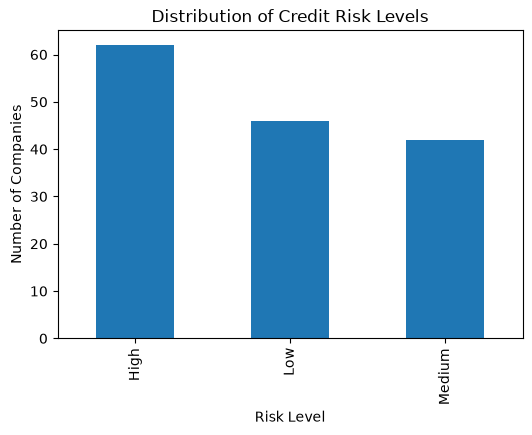

In [46]:
plt.figure(figsize=(6,4))

df["Predicted_Risk"].value_counts().plot(kind="bar")

plt.title("Distribution of Credit Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Number of Companies")

plt.show()

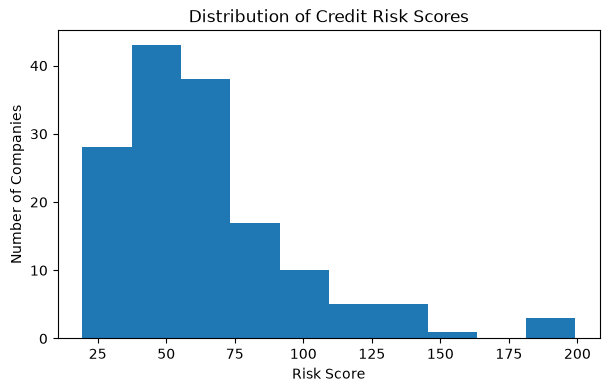

In [47]:
plt.figure(figsize=(7,4))

plt.hist(df["Risk_Score"], bins=10)

plt.title("Distribution of Credit Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Number of Companies")

plt.show()

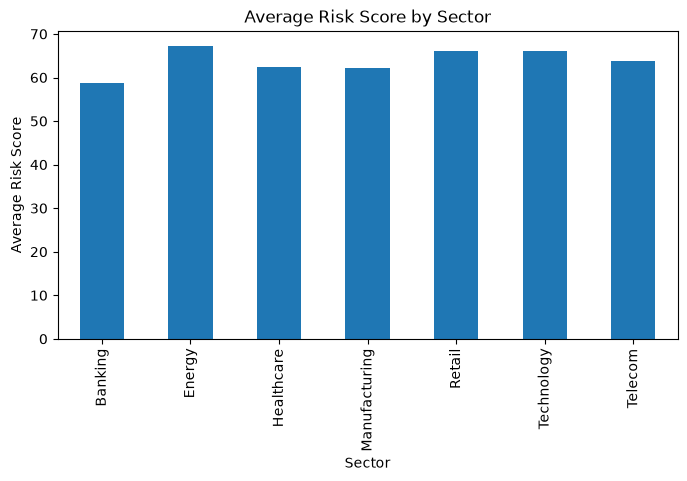

In [48]:
sector_avg = df.groupby("Sector")["Risk_Score"].mean()

plt.figure(figsize=(8,4))

sector_avg.plot(kind="bar")

plt.title("Average Risk Score by Sector")
plt.xlabel("Sector")
plt.ylabel("Average Risk Score")

plt.show()

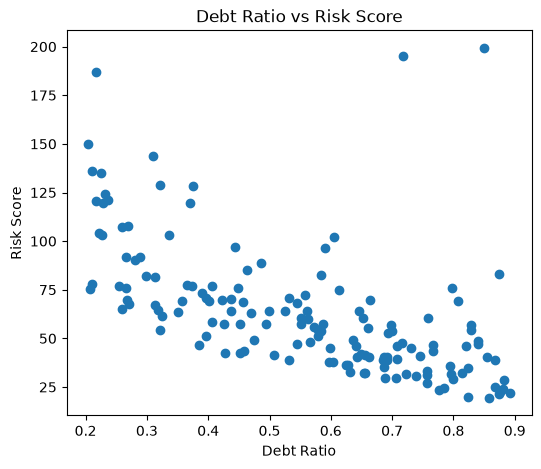

In [49]:
plt.figure(figsize=(6,5))

plt.scatter(df["Debt_Ratio"], df["Risk_Score"])

plt.title("Debt Ratio vs Risk Score")
plt.xlabel("Debt Ratio")
plt.ylabel("Risk Score")

plt.show()